**Install & Import Libraries**

In [41]:
!pip install tensorflow

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

**Upload & Load Dataset**

In [43]:
from google.colab import files

df = pd.read_csv("EV_Charging_Load_Demand_Dataset.csv")
df.head()

,timestep_sec,minute_of_hour,vehicle_id,speed_ms,acceleration_ms2,soc_percent,energy_consumed_Wh,lane_id,status,current_station_id,...,system_moving_vehicles,system_charging_vehicles,system_waiting_vehicles,system_avg_speed_ms,system_avg_soc_percent,system_avg_moving_speed_ms,system_avg_moving_soc_percent,system_avg_charging_soc_percent,system_avg_charging_duration_sec,system_total_load_kW
0,1.0,0,easyBike_001,0.82,0.92,43.17,0.05,E0_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
1,1.0,0,easyBike_002,0.84,1.15,42.00,0.06,E0_1,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
2,1.0,0,easyBike_003,0.81,0.49,40.83,0.05,E4_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
3,1.0,0,easyBike_005,0.88,0.77,38.50,0.06,NEG_E3_0,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0
4,1.0,0,easyBike_006,0.90,1.13,37.33,0.06,NEG_E8_1,driving,none,...,8,0,0,0.87,38.35,0.87,38.35,0.0,0.0,0.0


**Preprocessing**

In [44]:
# Fill missing
df['lane_id'] = df['lane_id'].fillna('unknown')

# Drop leakage + noise
df = df.drop(columns=['station_load_kW'])
df = df.drop(columns=['vehicle_id', 'lane_id', 'current_station_id'])

# Encode categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

**Sort by Time**

In [45]:
df = df.sort_values(by='timestep_sec')

**Define Features & Target**

In [46]:
X = df.drop(columns=['system_total_load_kW']).values
y = df['system_total_load_kW'].values

**Scale Data (VERY IMPORTANT for LSTM)**

In [47]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

**Create Time Sequences (CORE STEP)**

In [48]:
def create_sequences(X, y, time_steps=10):
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])

    return np.array(X_seq), np.array(y_seq)

time_steps = 10

X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

**Train-Test Split (NO SHUFFLE!)**

In [49]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

**Build LSTM Model**

In [50]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(time_steps, X.shape[1])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [51]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 0.0084 - val_loss: 2.4024e-04
Epoch 2/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0033 - val_loss: 0.0016
Epoch 3/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0022 - val_loss: 8.2081e-04
Epoch 4/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0015 - val_loss: 9.4580e-04
Epoch 5/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0012 - val_loss: 4.1792e-04
Epoch 6/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 9.7654e-04 - val_loss: 0.0013
Epoch 7/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.9707e-04 - val_loss: 0.0012
Epoch 8/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 8.9055e-04 - val_loss: 0.0011
Epoch 9/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 8.2886e-04 - val_loss: 3.8411e-04
Epoch 10/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 8.2000e-04 - val_loss: 0.0011


**Predictions & Inverse Scaling**

In [52]:
y_pred = model.predict(X_test)

# Inverse scale
y_pred_inv = scaler_y.inverse_transform(y_pred)
# y_test_inv = scaler_y.inverse_transform(y_test)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1))

211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


**Evaluation**

In [53]:
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("LSTM Results")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

LSTM Results
MAE: 42.1827
RMSE: 45.6130
R2: -4.7956


**Plot Results**

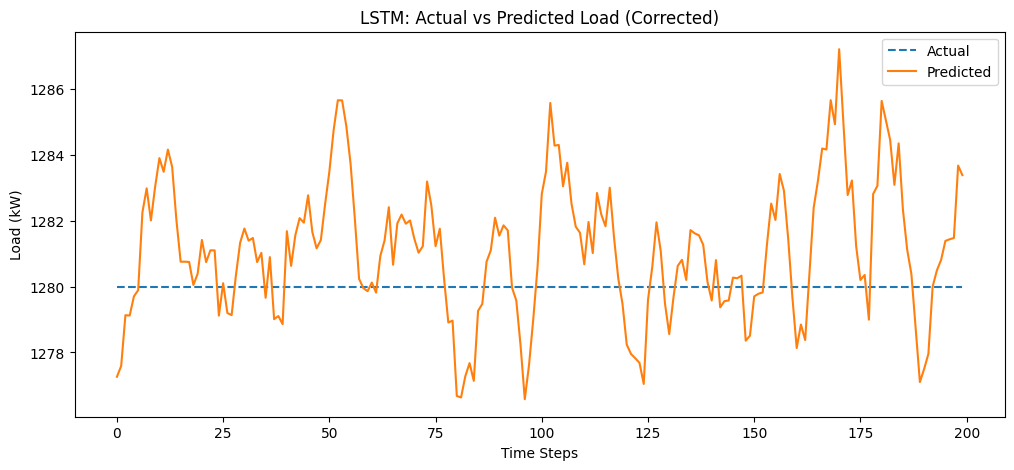

In [54]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv[:200].flatten(), label='Actual', linestyle='dashed')
plt.plot(y_pred_inv[:200].flatten(), label='Predicted')

plt.legend()
plt.title("LSTM: Actual vs Predicted Load (Corrected)")
plt.xlabel("Time Steps")
plt.ylabel("Load (kW)")

plt.show()